In [1]:
!pip3 install pandas

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('de_tag.csv')
print(df)

   target  en_ppf_u  en_ppf_e  en_spt  en_cpr  en_prs  de_ppf  de_spt  \
0     PRS         0         0       0       0       1       0       0   
1     PRS         1         0       0       0       0       0       0   
2     PPF         0         1       0       0       0       1       0   
3     PPF         0         0       1       0       0       1       0   
4     PPF         0         0       1       0       0       1       0   
..    ...       ...       ...     ...     ...     ...     ...     ...   
74  SPT_B         0         0       1       0       0       0       0   
75    PPF         0         1       0       0       0       1       0   
76    PRS         0         0       0       0       1       0       0   
77    PRS         0         0       0       0       1       0       0   
78    PRS         0         0       0       0       1       0       0   

    de_spt_b  de_prs  ...  ka_fsj  ka_con  ka_opt  ka_prs  zh_non  zh_le  \
0          0       1  ...       0       0      

In [4]:
df.head()

,target,en_ppf_u,en_ppf_e,en_spt,en_cpr,en_prs,de_ppf,de_spt,de_spt_b,de_prs,...,ka_fsj,ka_con,ka_opt,ka_prs,zh_non,zh_le,zh_guo,zh_you,zh_shi,zh_oth
0,PRS,0,0,0,0,1,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
1,PRS,1,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,PPF,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,PPF,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,PPF,0,0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [5]:
features = ['en_ppf_u', 'en_ppf_e', 'en_spt', 'en_cpr', 'en_prs', 'de_ppf', 'de_spt', 'de_spt_b', 'de_prs', 'es_ppf', 'es_ppf_p', 'es_spt', 'es_ipf', 'es_prs', 'es_ppg', 'ka_ppf', 'ka_spf', 'ka_aor', 'ka_ipf', 'ka_psj', 'ka_fsj', 'ka_con', 'ka_opt', 'ka_prs', 'zh_non', 'zh_le', 'zh_guo', 'zh_you', 'zh_shi', 'zh_oth']
x = df.loc[:, features].values

In [6]:
y = df.loc[:,['target']].values

In [7]:
x = StandardScaler().fit_transform(x)

In [8]:
pd.DataFrame(data = x, columns = features).head()

,en_ppf_u,en_ppf_e,en_spt,en_cpr,en_prs,de_ppf,de_spt,de_spt_b,de_prs,es_ppf,...,ka_fsj,ka_con,ka_opt,ka_prs,zh_non,zh_le,zh_guo,zh_you,zh_shi,zh_oth
0,-0.358569,-0.640870,-0.761577,-0.113228,1.909727,-0.825137,-0.443813,-0.4022,1.560379,-0.803638,...,-0.113228,-0.161165,0.0,1.560379,-1.065427,-0.443813,2.626785,-0.259938,-0.113228,-0.335673
1,2.788867,-0.640870,-0.761577,-0.113228,-0.523635,-0.825137,-0.443813,-0.4022,1.560379,-0.803638,...,-0.113228,-0.161165,0.0,-0.640870,0.938591,-0.443813,-0.380693,-0.259938,-0.113228,-0.335673
2,-0.358569,1.560379,-0.761577,-0.113228,-0.523635,1.211920,-0.443813,-0.4022,-0.640870,1.244342,...,-0.113228,-0.161165,0.0,-0.640870,-1.065427,-0.443813,2.626785,-0.259938,-0.113228,-0.335673
3,-0.358569,-0.640870,1.313064,-0.113228,-0.523635,1.211920,-0.443813,-0.4022,-0.640870,1.244342,...,-0.113228,-0.161165,0.0,-0.640870,-1.065427,-0.443813,2.626785,-0.259938,-0.113228,-0.335673
4,-0.358569,-0.640870,1.313064,-0.113228,-0.523635,1.211920,-0.443813,-0.4022,-0.640870,1.244342,...,-0.113228,-0.161165,0.0,-0.640870,0.938591,-0.443813,-0.380693,-0.259938,-0.113228,-0.335673


In [9]:
pca = PCA(n_components=2)

In [10]:
principalComponents = pca.fit_transform(x)

In [11]:
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])

In [12]:
principalDf.head(5)

,principal component 1,principal component 2
0,3.172453,-0.983740
1,1.804429,0.161726
2,-2.388125,-2.561704
3,-2.226806,-0.869903
4,-1.687359,-0.242528


In [13]:
df[['target']].head()

,target
0,PRS
1,PRS
2,PPF
3,PPF
4,PPF


In [14]:
finalDf = pd.concat([principalDf, df[['target']]], axis = 1)
finalDf.head(5)

,principal component 1,principal component 2,target
0,3.172453,-0.983740,PRS
1,1.804429,0.161726,PRS
2,-2.388125,-2.561704,PPF
3,-2.226806,-0.869903,PPF
4,-1.687359,-0.242528,PPF


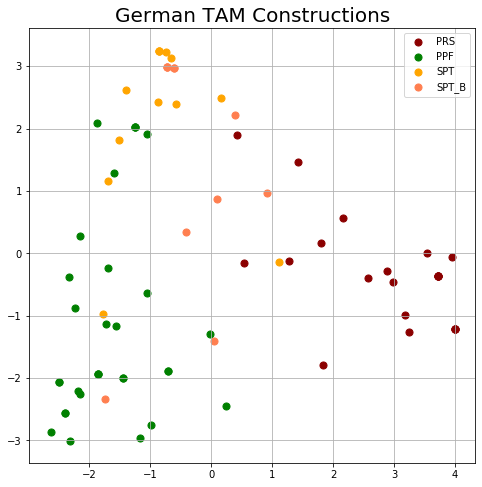

In [17]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_title('German TAM Constructions', fontsize = 20)


targets = ['PRS', 'PPF', 'SPT', 'SPT_B']
colors = ['darkred', 'green', 'orange', 'coral']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

In [18]:
pca.explained_variance_ratio_

array([0.14936592, 0.12447988])